# Telco Customer Segmentation with K-Means
### Tutorial Walkthrough — Question 3.1

**Scenario.** A telecom company has 300 customers with four features: `tenure` (months), `monthly_charges`, `total_charges`, and `contract` (`month-to-month`, `one-year`, `two-year`). We need to segment them with K-Means.

**Three things this notebook will demonstrate:**
1. **Data preparation** — encoding `contract` and scaling the numeric features.
2. **Choosing K** — using the Elbow Method on inertia.
3. **Scoring new customers** — assigning unseen customers to clusters without retraining.

> **TA tip.** Pause at each "Why this matters" callout — those are the conceptual questions students will see again on the assessment.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

np.random.seed(42)
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True

## Step 0 — Build the dataset

We don't have a real Telco file, so we simulate 300 customers with three natural segments built in. Students should know the *truth* is hidden from K-Means — the algorithm has to rediscover it from distances alone.

In [2]:
n = 100  # customers per latent segment

# Segment A: new month-to-month customers (low tenure, varied charges)
tenure_a  = np.random.randint(1, 13, n)
monthly_a = np.random.uniform(20, 80, n)

# Segment B: mid-term one-year contracts
tenure_b  = np.random.randint(13, 37, n)
monthly_b = np.random.uniform(50, 95, n)

# Segment C: long-term two-year loyal customers
tenure_c  = np.random.randint(37, 73, n)
monthly_c = np.random.uniform(70, 120, n)

tenure   = np.concatenate([tenure_a,  tenure_b,  tenure_c])
monthly  = np.concatenate([monthly_a, monthly_b, monthly_c])
contract = ['month-to-month']*n + ['one-year']*n + ['two-year']*n
total    = (tenure * monthly + np.random.normal(0, 50, len(tenure))).round(2)

df = pd.DataFrame({
    'tenure':          tenure,
    'monthly_charges': monthly.round(2),
    'total_charges':   total,
    'contract':        contract,
})

# Shuffle so the three segments are not in order
df = df.sample(frac=1, random_state=1).reset_index(drop=True)
df.head()

,tenure,monthly_charges,total_charges,contract
0,31,79.57,2519.39,one-year
1,28,59.40,1549.34,one-year
2,26,58.23,1469.91,one-year
3,70,104.40,7274.09,two-year
4,32,89.76,2939.39,one-year


In [3]:
df.describe()

,tenure,monthly_charges,total_charges
count,300.000000,300.000000,300.000000
mean,29.283333,71.391500,2501.500900
std,22.077161,24.293011,2360.026739
min,1.000000,20.030000,7.200000
25%,10.000000,54.047500,466.175000
50%,24.500000,71.730000,1605.175000
75%,48.000000,88.977500,4316.080000
max,72.000000,119.800000,8488.720000


**Observation — look at the ranges.**

| feature | min | max |
|---|---|---|
| tenure | 1 | 72 |
| monthly_charges | ~20 | ~120 |
| total_charges | ~7 | ~8500 |

`total_charges` spans ~8500 while `tenure` only spans 72. This **70× scale gap** is exactly what makes scaling non-negotiable for K-Means. Hold on to this fact — we'll prove it visually in a moment.

## Step 1 — Encode the `contract` column

`contract` is categorical, but it has a **natural ordering** based on commitment level:

`month-to-month` (0) → `one-year` (1) → `two-year` (2)

Because the order is meaningful, we use **label encoding**, not one-hot. Label encoding preserves that progression in a single column, and K-Means can use it as a numeric feature.

> **Why not one-hot?** One-hot would create three sparse 0/1 columns. Distances would be skewed and we'd lose the ordering. For ordered categories, label encoding is cleaner.

In [4]:
contract_map = {'month-to-month': 0, 'one-year': 1, 'two-year': 2}
df['contract_enc'] = df['contract'].map(contract_map)
df.head()

,tenure,monthly_charges,total_charges,contract,contract_enc
0,31,79.57,2519.39,one-year,1
1,28,59.40,1549.34,one-year,1
2,26,58.23,1469.91,one-year,1
3,70,104.40,7274.09,two-year,2
4,32,89.76,2939.39,one-year,1


## Step 2 — Why scaling matters (live demo)

Before we apply scaling, let's run K-Means on the **raw, unscaled** features and look at the cluster centers. We expect `total_charges` to swallow every other feature.

In [5]:
features = ['tenure', 'monthly_charges', 'total_charges', 'contract_enc']
X_raw = df[features].values

km_unscaled = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_unscaled = km_unscaled.fit_predict(X_raw)

centers_unscaled = pd.DataFrame(km_unscaled.cluster_centers_, columns=features)
centers_unscaled.round(2)

,tenure,monthly_charges,total_charges,contract_enc
0,63.10,102.80,6460.27,2.00
1,12.81,55.68,759.67,0.42
2,41.32,83.57,3462.70,1.59


**What do we see?** The three centers are essentially distinguished by `total_charges` (values like ~760, ~3460, ~6460). The differences in `tenure`, `monthly_charges`, and `contract_enc` exist but are dwarfed by the `total_charges` axis.

In Euclidean distance, a difference of 1 month in tenure is worth a difference of $1 in total charges. Since total charges range to ~8500 and tenure to 72, **K-Means is clustering almost entirely on total charges.** The other features are invisible.

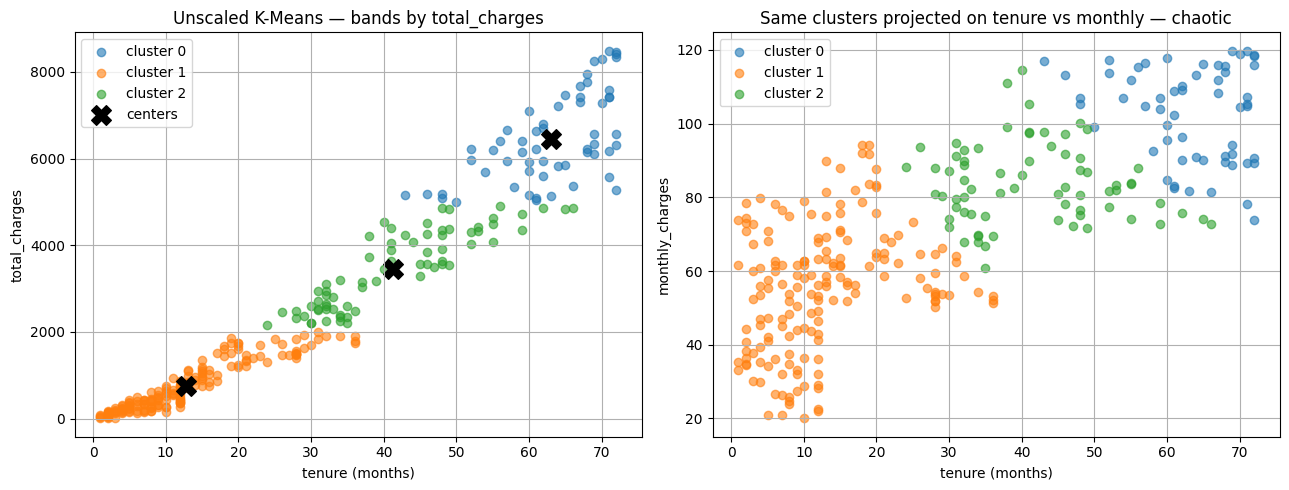

In [6]:
# Visualize: clusters from unscaled K-Means, plotted on tenure vs total_charges
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for c in range(3):
    mask = labels_unscaled == c
    ax.scatter(df.loc[mask, 'tenure'], df.loc[mask, 'total_charges'], label=f'cluster {c}', alpha=0.6)
ax.scatter(km_unscaled.cluster_centers_[:, 0], km_unscaled.cluster_centers_[:, 2],
           c='black', marker='X', s=200, label='centers')
ax.set_xlabel('tenure (months)')
ax.set_ylabel('total_charges')
ax.set_title('Unscaled K-Means — bands by total_charges')
ax.legend()

ax = axes[1]
for c in range(3):
    mask = labels_unscaled == c
    ax.scatter(df.loc[mask, 'tenure'], df.loc[mask, 'monthly_charges'], label=f'cluster {c}', alpha=0.6)
ax.set_xlabel('tenure (months)')
ax.set_ylabel('monthly_charges')
ax.set_title('Same clusters projected on tenure vs monthly — chaotic')
ax.legend()
plt.tight_layout()
plt.show()

**Read the right plot.** When we project the unscaled clusters onto `tenure` vs `monthly_charges`, the colors are mixed — clusters don't separate cleanly. That's because the algorithm never really used those axes. Only `total_charges` mattered.

This is exactly the bias the question is asking about. Now let's fix it.

## Step 2 (continued) — Apply `StandardScaler`

`StandardScaler` transforms each column to **mean = 0, std = 1**, putting every feature on the same numerical footing.

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Sanity check: mean ~ 0, std ~ 1 for every column
pd.DataFrame(X_scaled, columns=features).describe().round(3).loc[['mean', 'std']]

,tenure,monthly_charges,total_charges,contract_enc
mean,-0.000,-0.000,0.000,0.000
std,1.002,1.002,1.002,1.002


Every feature now has mean 0 and std 1. A move of 1 unit in tenure costs the same as a move of 1 unit in total_charges. Distance is fair.

## Step 3 — The Elbow Method to choose K

For each candidate K from 1 to 10, we fit K-Means and record **inertia** (within-cluster sum of squared distances). We look for the "elbow" — the K where adding more clusters stops paying off.

In [8]:
inertias = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

pd.DataFrame({'K': list(K_range), 'inertia': [round(i, 1) for i in inertias]})

,K,inertia
0,1,1200.0
1,2,351.3
2,3,192.0
3,4,139.9
4,5,106.8
5,6,82.2
6,7,67.7
7,8,58.4
8,9,50.2
9,10,44.0


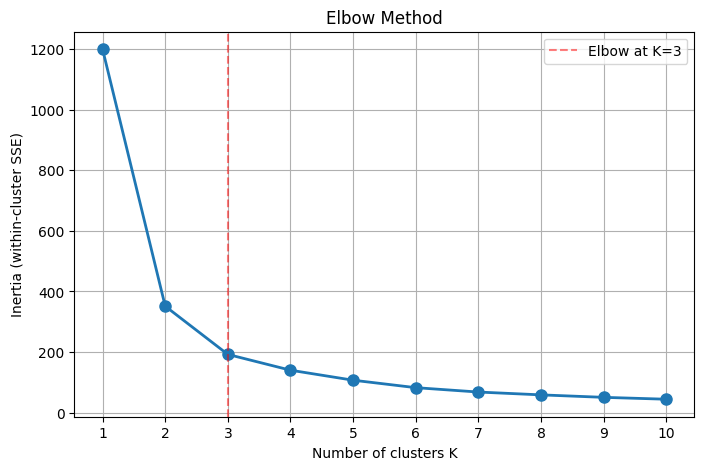

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'o-', linewidth=2, markersize=8)
plt.axvline(x=3, color='red', linestyle='--', alpha=0.5, label='Elbow at K=3')
plt.xlabel('Number of clusters K')
plt.ylabel('Inertia (within-cluster SSE)')
plt.title('Elbow Method')
plt.xticks(K_range)
plt.legend()
plt.show()

**How to read the elbow.**

- Inertia **always** decreases as K grows — at K = number-of-rows it would be zero. So we can't just minimize it.
- We're looking for the **bend** — the point where the curve goes from a steep cliff to a gentle slope.
- Here the drop from K=1 (≈1200) to K=3 (≈192) is dramatic, but K=3 to K=4 is small (192 → 140). That's the elbow.

> **Common student trap.** "Lower inertia is better" — true *for a fixed K*, false across K values. The elbow says: *diminishing returns set in here.*

We choose **K = 3**.

## Step 4 — Fit the final model and profile the clusters

In [10]:
final_km = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = final_km.fit_predict(X_scaled)

# Average characteristics per cluster (shown in original units)
profile = df.groupby('cluster')[features].mean().round(2)
profile['n_customers'] = df.groupby('cluster').size()
profile

,tenure,monthly_charges,total_charges,contract_enc,n_customers
cluster,,,,,
0,24.03,69.86,1691.38,1.0,100
1,7.04,48.53,343.31,0.0,100
2,56.78,95.78,5469.82,2.0,100


**Reading the profile.** Every cluster has a clear personality — and notice how `contract_enc` is almost integer-clean (1.0, 0.0, 2.0). That tells us K-Means recovered the contract structure even though contract was just one of four features.

| cluster | profile in plain English |
|---|---|
| **0** | mid-tenure (~24 mo), moderate charges, mostly **one-year** contracts |
| **1** | new customers (~7 mo), low charges, **month-to-month** |
| **2** | loyal long-tenure (~57 mo), high charges, **two-year** contracts |

This is a useful business segmentation: "new explorers", "stable mid-term", and "loyal high-value" customers.

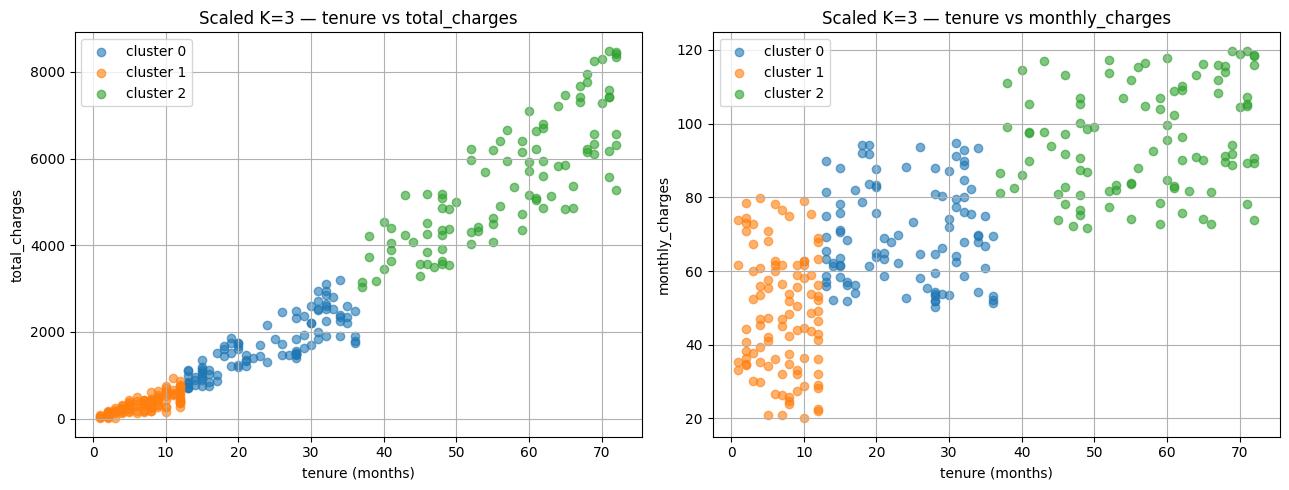

In [11]:
# Visualize the final clusters
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for c in range(3):
    mask = df['cluster'] == c
    ax.scatter(df.loc[mask, 'tenure'], df.loc[mask, 'total_charges'], label=f'cluster {c}', alpha=0.6)
ax.set_xlabel('tenure (months)')
ax.set_ylabel('total_charges')
ax.set_title('Scaled K=3 — tenure vs total_charges')
ax.legend()

ax = axes[1]
for c in range(3):
    mask = df['cluster'] == c
    ax.scatter(df.loc[mask, 'tenure'], df.loc[mask, 'monthly_charges'], label=f'cluster {c}', alpha=0.6)
ax.set_xlabel('tenure (months)')
ax.set_ylabel('monthly_charges')
ax.set_title('Scaled K=3 — tenure vs monthly_charges')
ax.legend()
plt.tight_layout()
plt.show()

Compare these plots to the unscaled version earlier. The clusters now separate **cleanly on multiple axes**, not just total_charges. That's what proper scaling buys you.

## Step 5 — Assigning a new customer (no retraining)

This is the part students miss most often. To score a new customer:

1. Encode `contract` with the **same map** used in training.
2. Apply the **same fitted scaler** (`scaler.transform`, *not* `fit_transform`).
3. Call `final_km.predict(...)` — K-Means simply finds the nearest saved centroid.

The model and scaler are reused. No retraining.

In [12]:
# A new month-to-month customer, 6 months in, ~$55/mo, ~$330 total
new_customer = pd.DataFrame([{
    'tenure':          6,
    'monthly_charges': 55,
    'total_charges':   330,
    'contract_enc':    contract_map['month-to-month'],
}])
new_customer

,tenure,monthly_charges,total_charges,contract_enc
0,6,55,330,0


In [13]:
# Step 1: scale with the SAME scaler
new_scaled = scaler.transform(new_customer[features].values)

# Step 2: predict cluster
predicted = final_km.predict(new_scaled)[0]
print(f'New customer assigned to cluster: {predicted}')

# Show distances to each centroid (this is exactly what predict() does internally)
print('\nDistances to each centroid (in scaled space):')
for i, centroid in enumerate(final_km.cluster_centers_):
    dist = np.sqrt(((new_scaled[0] - centroid) ** 2).sum())
    marker = '  <-- nearest' if i == predicted else ''
    print(f'  cluster {i}: {dist:.3f}{marker}')

New customer assigned to cluster: 1

Distances to each centroid (in scaled space):
  cluster 0: 1.697
  cluster 1: 0.271  <-- nearest
  cluster 2: 4.347


**Mechanically what happened.**
- The new customer was scaled into the same coordinate space the model trained in.
- We computed Euclidean distance to all three saved centroids.
- The smallest distance wins — that's the assigned cluster.

The K-Means model itself never changed. This is what makes K-Means usable in production: train once, score forever (until the data drifts enough to retrain).

## What if we forgot to scale the new customer?

A common bug. Let's see what would happen.

In [14]:
# Wrong: pass raw values to a model trained on scaled data
wrong_pred = final_km.predict(new_customer[features].values)[0]
print(f'WITHOUT scaling: cluster {wrong_pred}  <- WRONG ANSWER')
print(f'WITH    scaling: cluster {predicted}  <- CORRECT')

WITHOUT scaling: cluster 2  <- WRONG ANSWER
WITH    scaling: cluster 1  <- CORRECT


The unscaled prediction lands in the wrong cluster because the centroids live in scaled space. **Always reuse the same scaler.** Save it next to your model.

## Summary — what the assessment is testing

| Concept | What students must say |
|---|---|
| **Encoding** | `contract` is ordinal → label encode (0, 1, 2). Don't one-hot. |
| **Scaling** | `total_charges` ~ 70× the range of `tenure`. Without `StandardScaler`, K-Means clusters only on total_charges. |
| **K selection** | Plot inertia vs K. Choose K at the bend. Lowest inertia is *not* the goal. |
| **Scoring new data** | Reuse the fitted scaler and the fitted K-Means. `predict()` finds the nearest centroid. No retraining. |

> **TA closing line.** "If you remember one thing: distance-based algorithms demand scaled features. Forget scaling and your model is a single-feature model in disguise."